<a href="https://colab.research.google.com/github/ANSH76564/task2/blob/main/MLTASK2_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Non-Spam / Ham Data

Ham means a normal, genuine message that is not unwanted spam.

Examples from a typical SMS dataset:

"Hey, are we meeting today?"
"Can you send me the notes?"
"Where are you?"
"Your appointment is tomorrow."

Spam Data

Spam means an unwanted or suspicious message, often involving advertisements, fake prizes, promotions, or requests to take some action.

Examples:

"Congratulations! You have won a free prize!"
"Claim your cash reward now!"
"URGENT! You have won a lottery."
"Get a special offer. Call now!"

SPAM - 1
NON-SPAM - 0

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re



In [54]:

df = pd.read_csv("spam (1).csv", encoding="latin-1")


df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [55]:

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)


print("\nDataset Information:")
df.info()

Dataset Shape: (5572, 5)

Column Names:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [56]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


CHANGING THE COLUMNS MANE

In [57]:
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']]
    df.columns = ['label', 'message']
    print("Columns 'v1' and 'v2' selected and renamed to 'label' and 'message'.")
elif 'label' in df.columns and 'message' in df.columns:
    print("DataFrame already has 'label' and 'message' columns. Skipping rename.")
else:
    print("Warning: DataFrame columns are not 'v1', 'v2' or 'label', 'message'.")
    print("Current columns:", df.columns.tolist())

df.head()

DataFrame already has 'label' and 'message' columns. Skipping rename.


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [58]:

print("Missing values:")
print(df.isnull().sum())

Missing values:
label      0
message    0
dtype: int64


In [59]:

df = df.dropna()

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
label      0
message    0
dtype: int64


In [60]:

print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 403


In [61]:

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [62]:

print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


GRAPHS BETWEENT THE SPAM AND NON SPAM

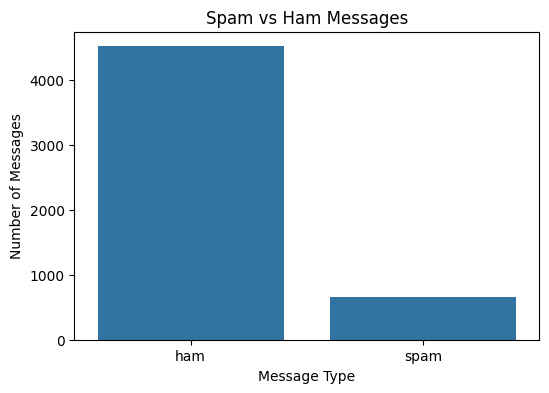

In [63]:
plt.figure(figsize=(6, 4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

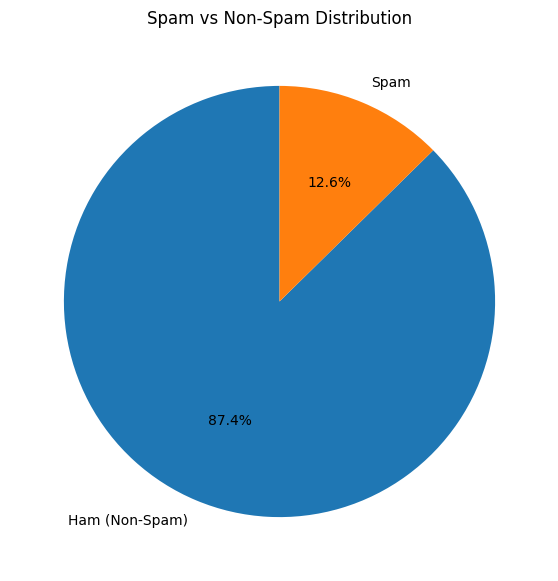

In [64]:
# Count Spam and Ham
label_counts = df['label'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    label_counts,
    labels=['Ham (Non-Spam)', 'Spam'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Spam vs Non-Spam Distribution')

plt.show()

In [65]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


analysing the text that have spam

In [34]:
import string

# Standard English stop words
STOPWORDS = set([
    "!", "\"", "#", "$", "%", "&", "'", "(", ")", "*", "+", ",", "-", ".", "/",
    ":", ";", "<", "=", ">", "?", "@", "[", "\\", "]", "^", "_", "`", "{", "|", "}", "~",



    "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are",
    "as", "at", "be", "because", "been", "before", "being", "below", "between", "both", "but",
    "by", "can", "could", "did", "do", "does", "doing", "down", "during", "each", "few", "for",
    "from", "further", "had", "has", "have", "having", "he", "her", "here", "hers", "herself",
    "him", "himself", "his", "how", "i", "if", "in", "into", "is", "it", "its", "itself", "just",
    "me", "more", "most", "my", "myself", "no", "nor", "not", "of", "off", "on", "once", "only",
    "or", "other", "our", "ours", "ourselves", "out", "over", "own", "same", "she", "should",
    "so", "some", "such", "than", "that", "the", "their", "theirs", "them", "themselves", "then",
    "there", "these", "they", "this", "those", "through", "to", "too", "under", "until", "up",
    "very", "was", "we", "were", "what", "when", "where", "which", "while", "who", "whom", "why",
    "with", "you", "your", "yours", "yourself", "yourselves"
])

def clean_text(text):
    text = text.lower()

    text = re.sub(f'[{re.escape(string.punctuation)}0-9]', '', text)

    tokens = text.split()
    cleaned = [word for word in tokens if word not in STOPWORDS]
    return ' '.join(cleaned)

df['cleaned_message'] = df['message'].apply(clean_text)
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [35]:
def clean_text(text):

    text = text.lower()


    text = re.sub(r'http\S+|www\S+|https\S+', '', text)


    text = re.sub(r'\S+@\S+', '', text)


    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [68]:
df['clean_message'] = df['message'].apply(clean_text)

df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [69]:
X = df['clean_message']
y = df['label_num']

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (5169,)
Labels: (5169,)


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [72]:

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [73]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [74]:

y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [75]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9671179883945842
Accuracy (%): 96.71179883945842


In [76]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.98989898989899


In [77]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.7480916030534351


In [78]:
f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)

F1-Score: 0.8521739130434782


In [79]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [80]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[902   1]
 [ 33  98]]


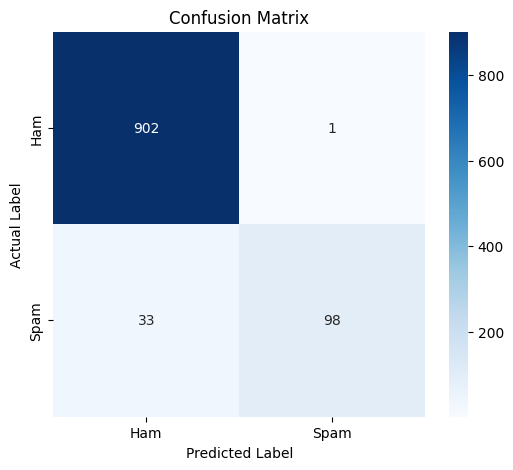

In [81]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Display All Evaluation Metrics Together

In [82]:
try:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    metrics_df = pd.DataFrame(
        metrics.items(),
        columns=['Metric', 'Score']
    )

    metrics_df
except NameError as e:
    if "name 'y_pred' is not defined" in str(e):
        print("Error: 'y_pred' is not defined. Please ensure the model prediction step (cell 58aYuZURJ_GI) has been executed.")
    else:
        raise e

Test New Messages

In [84]:
new_messages = [
    "Congratulations! You have won a free lottery ticket. Claim your prize now!",
    "Hey, are we meeting for lunch today?",
    "URGENT! You have won a cash prize. Call now to claim it.",
    "Can you send me the notes from today's class?",
    "You have been selected for a free gift. Click the link to claim."
]


clean_new_messages = [clean_text(msg) for msg in new_messages]

new_messages_tfidf = tfidf.transform(clean_new_messages)

predictions = model.predict(new_messages_tfidf)


for message, prediction in zip(new_messages, predictions):
    result = "SPAM" if prediction == 1 else "HAM"

    print("Message:", message)
    print("Prediction:", result)


Message: Congratulations! You have won a free lottery ticket. Claim your prize now!
Prediction: SPAM
Message: Hey, are we meeting for lunch today?
Prediction: HAM
Message: URGENT! You have won a cash prize. Call now to claim it.
Prediction: SPAM
Message: Can you send me the notes from today's class?
Prediction: HAM
Message: You have been selected for a free gift. Click the link to claim.
Prediction: SPAM


Final Prediction Table

In [85]:
prediction_results = pd.DataFrame({
    'Message': new_messages,
    'Prediction': [
        'Spam' if p == 1 else 'Ham'
        for p in predictions
    ]
})

prediction_results

,Message,Prediction
0,Congratulations! You have won a free lottery t...,Spam
1,"Hey, are we meeting for lunch today?",Ham
2,URGENT! You have won a cash prize. Call now to...,Spam
3,Can you send me the notes from today's class?,Ham
4,You have been selected for a free gift. Click ...,Spam


In [86]:
df.to_csv("cleaned_spam_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [88]:

print("SPAM CLASSIFIER - FINAL RESULTS")


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nModel: Multinomial Naive Bayes")
print("Feature Extraction: TF-IDF")
print("Classification: Spam vs Ham")

SPAM CLASSIFIER - FINAL RESULTS
Accuracy  : 0.9671
Precision : 0.9899
Recall    : 0.7481
F1-Score  : 0.8522

Model: Multinomial Naive Bayes
Feature Extraction: TF-IDF
Classification: Spam vs Ham
